In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit

%matplotlib inline
#from brokenaxes import brokenaxes


plt.rc('lines', linewidth=4)
plt.rc('legend',fontsize=16)
plt.rc('axes',labelsize=16)
plt.rc('xtick',labelsize=12)
plt.rc('xtick',direction='in')
plt.rc('ytick',labelsize=12)
plt.rc('axes',labelsize=16)
plt.rc('ytick',direction='in')
plt.rc('figure',figsize=(8,6))


In [2]:
dat = pd.read_csv('psf 400.txt',    names=('i','x','y')     )
dat852 = pd.read_csv('psf 852.txt',    header =14 , delimiter = '\t')


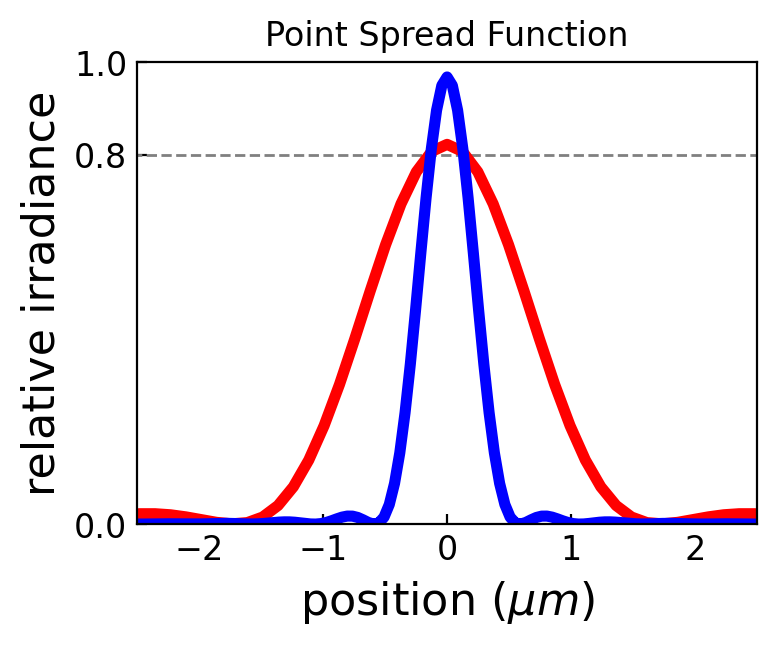

In [3]:
plt.figure(figsize =(4,3), dpi=200)
pmag = 125.9988
pmag852 = 7.57

plt.plot([-5,5],[.8,.8], color = 'grey', linestyle = '--', linewidth =1)
plt.plot(dat852['Position']/pmag852, dat852['Value'], color = 'r')

plt.plot(dat['x']/pmag, dat['y'], color = 'b')

#plt.plot([-.25,.25], [.5,.5])
plt.xlim(-2.5,2.5)

plt.ylim(0,1)
plt.yticks([0,.8,1])
plt.xlabel(r'position ($\mu m$)')
plt.ylabel(r'relative irradiance')
plt.title('Point Spread Function')
plt.savefig('psf.pdf')

images/1.1_1.1/20250728141212262_0.bmp
(3120, 4200)


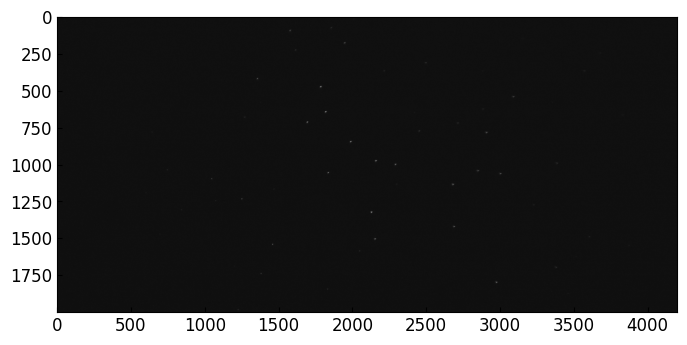

(2000, 4200)
(13, 3)


C:\Users\Tommy\AppData\Local\Temp\ipykernel_17432\2491957801.py:85: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


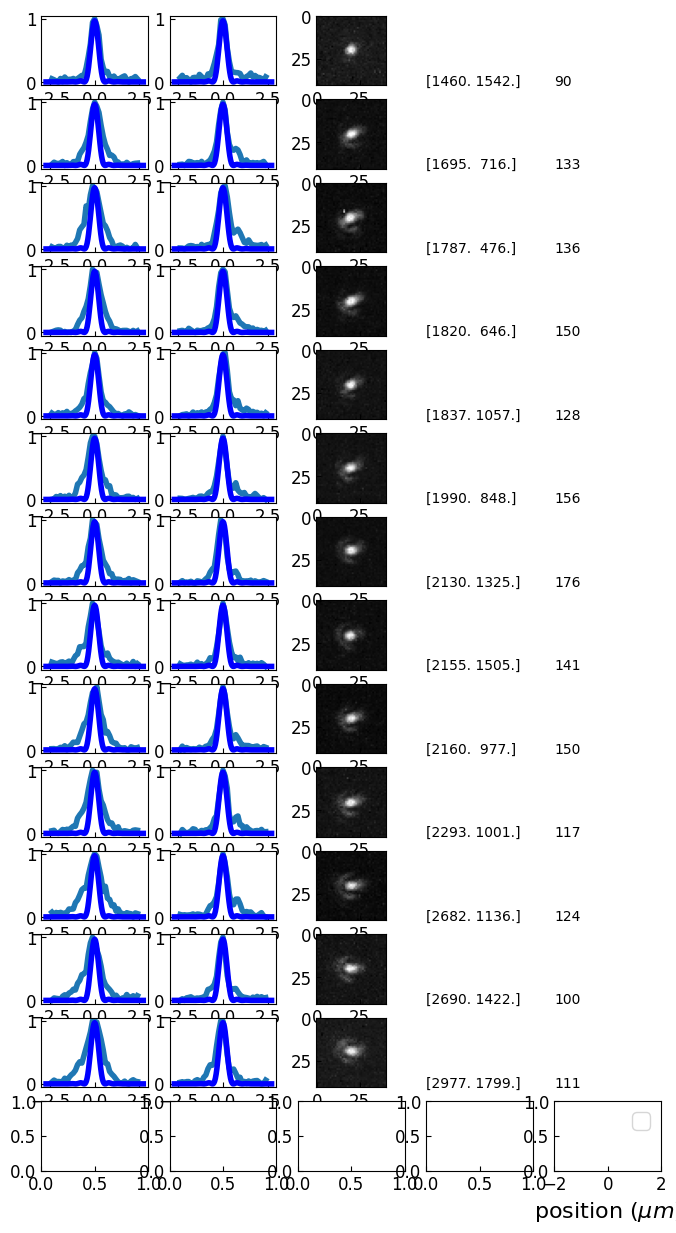

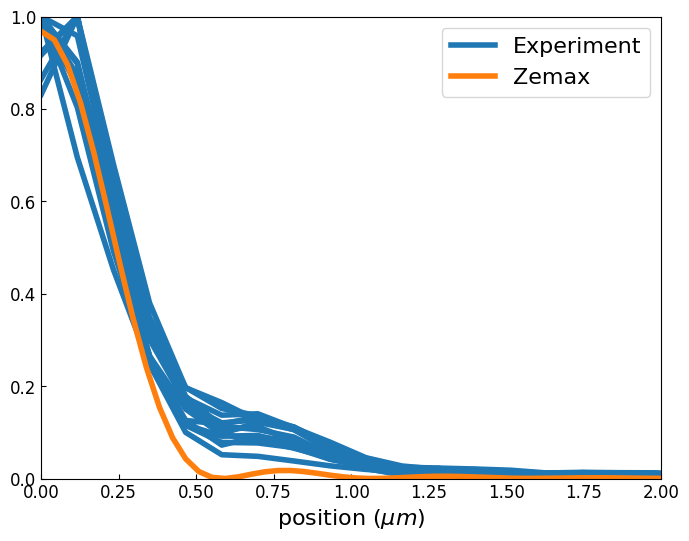

shape
(2000, 4200)


In [4]:
from PIL import Image
from operator import itemgetter


def radial_profile(data, center):
    y, x = np.indices((data.shape))
    r = np.sqrt((x - center[0])**2 + (y - center[1])**2)
    r = r.astype(int)

    tbin = np.bincount(r.ravel(), data.ravel())
    nr = np.bincount(r.ravel())
    radialprofile = tbin / nr
    return np.unique(r),radialprofile 

import os


directory = os.fsencode("images/1.1_1.1/")
stack = []
all_x0s=[]
all_y0s=[]
for i,file in enumerate(sorted(os.listdir(directory))[10:11]):
    # plt.figure(dpi=200)
    filename = os.fsdecode(directory+file)
    im = np.array(Image.open(filename))
    print(filename)
    print(np.shape(im))
    im = im[600:2600,:] 
    plt.imshow(im, cmap= 'Greys_r')
    plt.show()

    print(im.shape)




    from skimage.feature import blob_dog, blob_log, blob_doh

    blobs = blob_dog(im, max_sigma=10, threshold=0.1)
    print(np.shape(blobs))
    

    blobs = sorted(blobs,key=itemgetter(1))
    # for b in blobs:
    #     plt.plot(np.mean(b[0]),np.mean(b[1]))
    
    l=0
    if np.shape(blobs)[0] > 0:
        fig, axs = plt.subplots(len(blobs)+1,5)
        margin = 20
        fig.set_figheight(15)
        

        x0s=[]
        y0s=[]
        for b in blobs:
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
                
            if bim.shape == (41,41):
            
            
                for a in [0,1]:
                    
                    X_ = np.linspace(0, bim.shape[0])
                    X_ = np.linspace(0, bim.shape[0]/8.5875, bim.shape[0])
                    X_ = X_ - np.mean(X_)
                    Y_ = np.sum(bim, axis = a)
                    Y_ = Y_ - np.min(Y_)
                    Y_ = Y_ / np.max(Y_)
                    axs[l,a].plot(X_,Y_)       
                    axs[l,a].plot(dat['x']/pmag, dat['y'], color = 'b', label = 'Zemax')
                axs[l,2].imshow(bim, cmap= 'Greys_r')
                axs[l,3].axis('off')
                axs[l,3].text(0,0,np.array((np.mean(b[1]), np.mean(b[0]))))
                axs[l,4].axis('off')
                axs[l,4].text(0,0,np.max(bim))
                x0s.append(int(np.mean(b[1])))
                y0s.append(int(np.mean(b[0])))
            else:
                axs[l,0].remove()
                axs[l,1].remove()
                axs[l,2].remove()
                axs[l,3].remove()
                axs[l,4].remove()
            plt.legend()
            plt.xlim(-2,2)
            plt.xlabel(r'position ($\mu m$)')
            l+=1
        plt.show()  
            
        all_x0s.append(x0s)
        all_y0s.append(y0s)
       

    for b in blobs:
            
            bim = im[int(b[0]-20):int(b[0]+21),int(b[1])-20:int(b[1]+21)]
            if bim.shape == (41,41):
             
                X_ = np.linspace(0, bim.shape[0])
                X_,Y_ = radial_profile(bim, (20,20))
                Y_ = Y_ - np.min(Y_)
                Y_ = Y_ / np.max(Y_)
                plt.plot(X_/8.5875,Y_, color = 'C0')
            else:
                continue
    plt.plot([],[], color = 'C0', label = 'Experiment')
    plt.plot(dat['x']/pmag, dat['y'], color = 'C1', label = 'Zemax')
    plt.legend()
    plt.xlim(0,2)
    plt.ylim(0,1)
    plt.xlabel(r'position ($\mu m$)')
    plt.show()
    print('shape')
    print(np.shape(im))



[1460, 1695, 1787, 1820, 1837, 1990, 2130, 2155, 2160, 2293, 2682, 2690, 2977] [1542, 716, 476, 646, 1057, 848, 1325, 1505, 977, 1001, 1136, 1422, 1799]
images/1.1_1.1/20250728141157268_0.bmp
1837


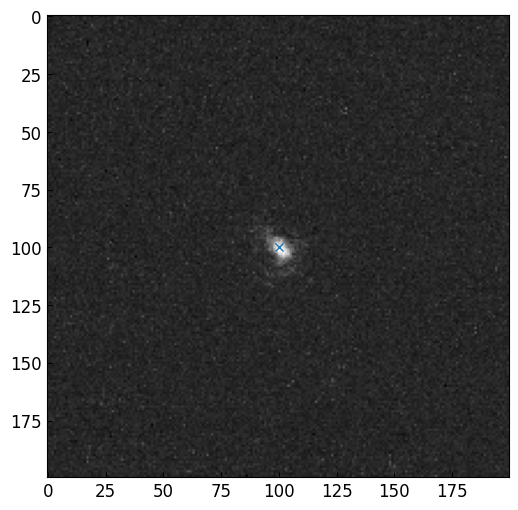

images/1.1_1.1/20250728141204765_0.bmp
1837


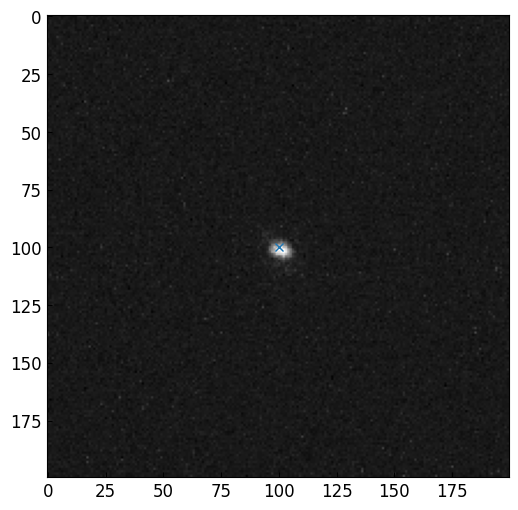

images/1.1_1.1/20250728141212262_0.bmp
1837


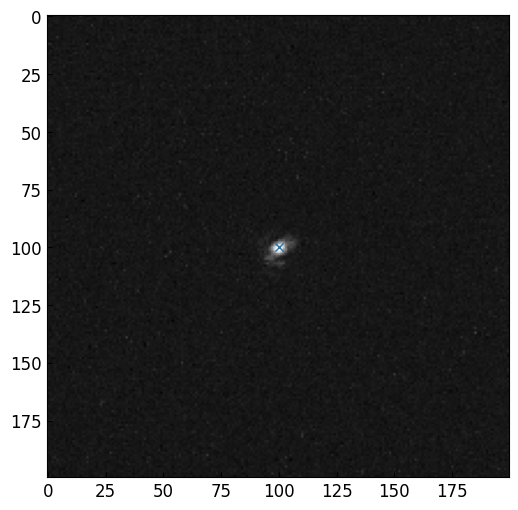

images/1.1_1.1/20250728141223494_0.bmp
1837


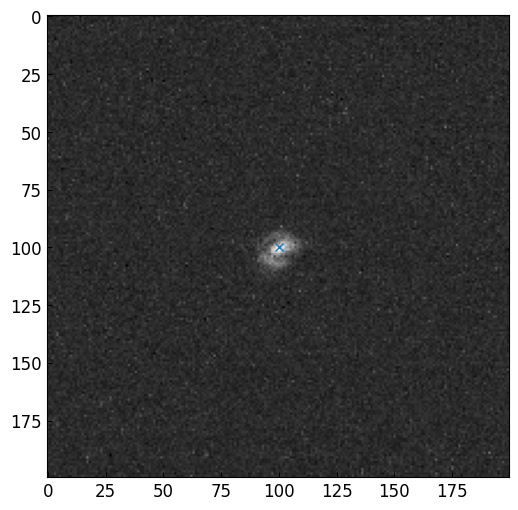

1.4984852318489958


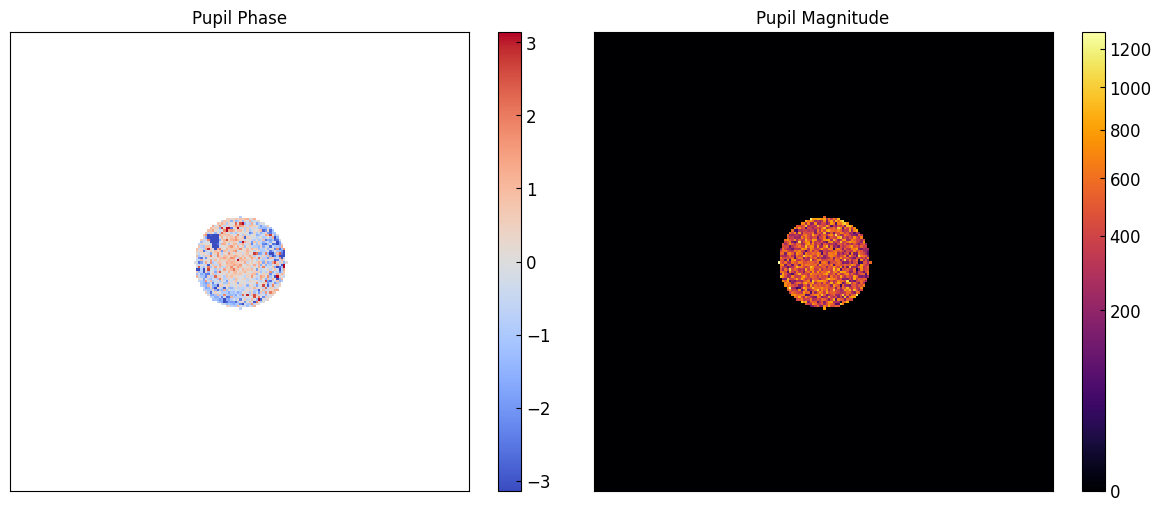

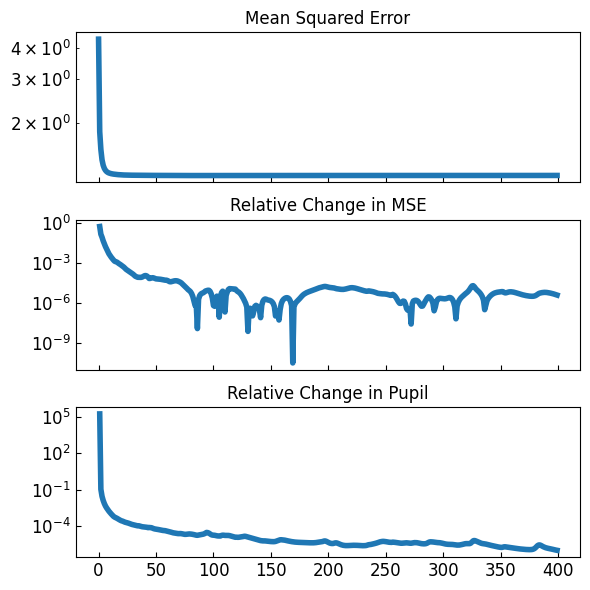

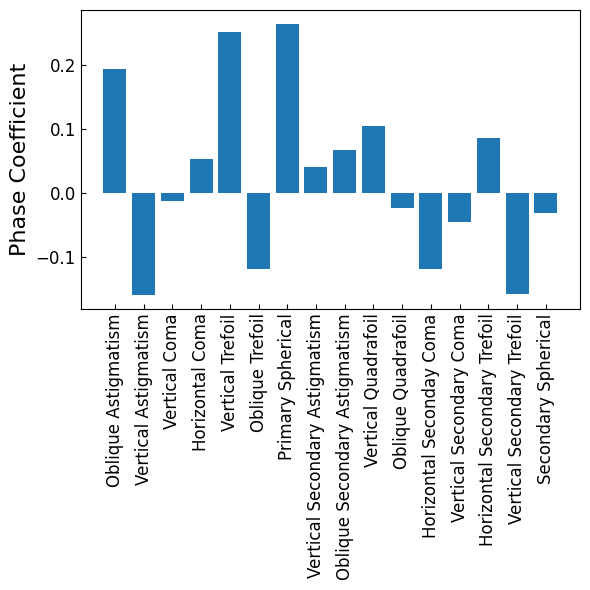

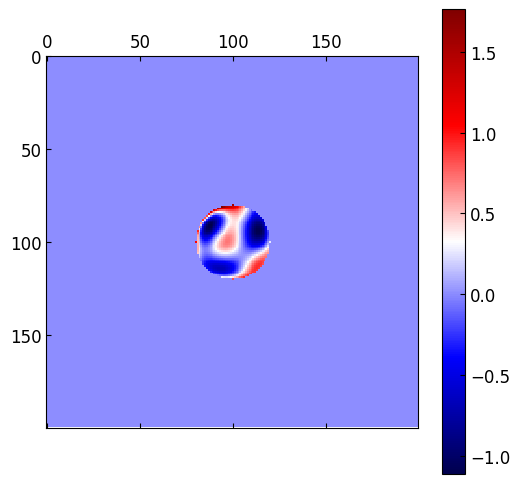

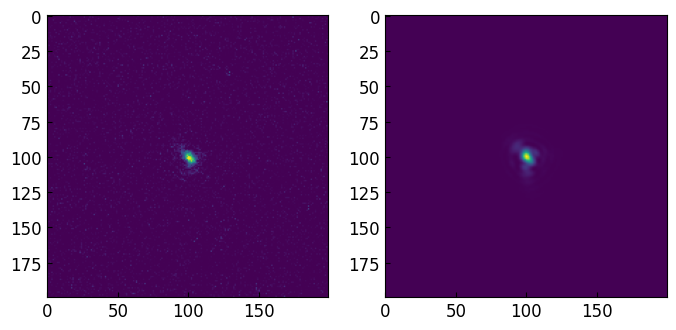

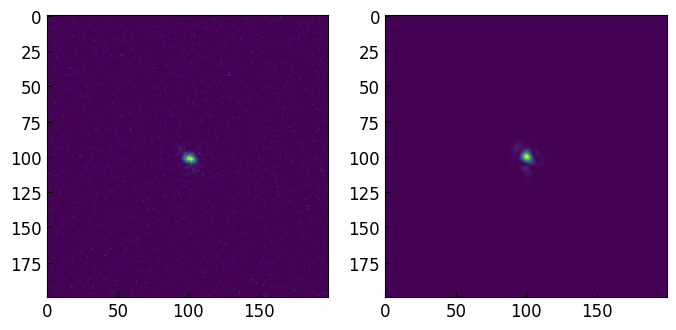

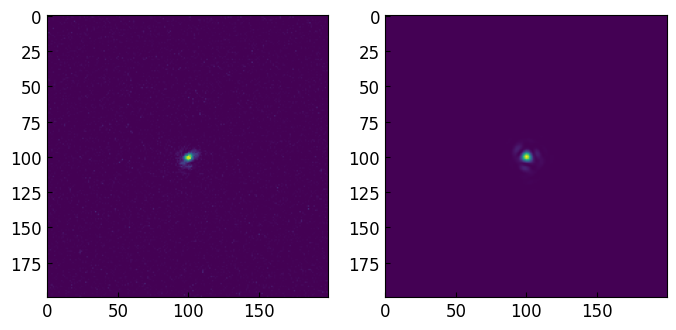

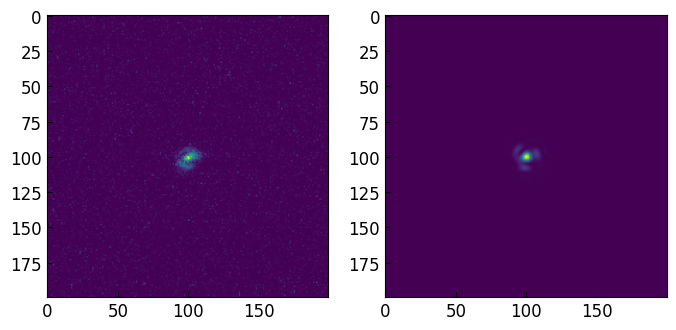

: 

In [ ]:
# Set Parameters

file_start = 8
file_stop = -10
blob = 4
length=100

x0_shift=0
y0_shift=200

xshift_fact = -0.2
yshift_fact = -.15

x0 = int(x0s[blob])+x0_shift
y0 = int(y0s[blob])+y0_shift

na = 0.35
zres = 100000/150*2
iters = 400
n_z = 20

# Main Code

print(x0s,y0s)

stack = []

for i,file in enumerate(sorted(os.listdir(directory))[file_start:file_stop]):


    filename = os.fsdecode(directory+file)

    print(filename)

    im = np.array(Image.open(filename))
    
    im = im[400:2600,:3000] 

    xshift = int(xshift_fact*i)

    yshift = int(yshift_fact*i)
    print(x0)

    p = np.array(im)[y0-length+yshift:y0+length+yshift,x0-length+xshift:x0+length+xshift]

    plt.plot([length,], [length,],'x')

    stack.append(p)

    plt.imshow(p, cmap = 'Greys_r')

    plt.show()

stack = np.array(stack[:])

 

test_data =stack

 

#from pyotf import HanserPSF

from pyotf.phaseretrieval import *

from pyotf.utils import *

 

params = dict(

    size=test_data.shape[-1],

    zsize=test_data.shape[0],

    na=na,

    res=114  ,

    zres=zres,

    wl=399,

    ni=1.0,

    vec_corr="none",

    condition="none",

)
 

params["size"] = 512

junk = prep_data_for_PR(test_data, None, 1.05)


result = retrieve_phase(junk, params, iters, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

result.plot()

result.plot_convergence()

zd_result = result.fit_to_zernikes(n_z)

zd_result.plot_named_coefs()

 

plt.matshow(zd_result.phase(slice(4, None, None)), cmap="seismic")

plt.colorbar()

print(result.rms_error)

plt.figure()

psf = result.generate_zd_psf()

for im,sim in zip(junk,psf):

    plt.subplot(1,2,1)

    plt.imshow(im)

   

    plt.subplot(1,2,2)

    plt.imshow(sim)

   

    

    plt.show()

In [12]:
blob_start = 4
blob_stop = 1
print(len(x0s) - blob_stop - blob_start)


coefs = []
xs=[]
ys=[]
ns=[]


for b in range(blob_start, len(x0s) - blob_stop):

    print(b)
    
    
    try:
        stack = []

        x0 = int(x0s[b]) + x0_shift
        y0 = int(y0s[b]) + y0_shift

        

        for i,file in enumerate(sorted(os.listdir(directory))[file_start:file_stop]):


            filename = os.fsdecode(directory+file)

            im = np.array(Image.open(filename))
            
            im = im[400:2600,:3000] 

            xshift = int(xshift_fact*i)

            yshift = int(yshift_fact*i)

            p = np.array(im)[y0-length+yshift:y0+length+yshift,x0-length+xshift:x0+length+xshift]
            # print(np.shape(p))

            stack.append(p)

        
        print(np.shape(stack))

        
        
        if np.shape(stack) != (len(sorted(os.listdir(directory))[file_start:file_stop]), 2*length,2*length):
            continue

        stack = np.array(stack)

        xs.append(x0s[b])
        ys.append(y0s[b])
        ns.append(b)
        
        test_data =stack

        #from pyotf import HanserPSF

        from pyotf.phaseretrieval import *

        from pyotf.utils import *

        params = dict(

            size=test_data.shape[-1],

            zsize=test_data.shape[0],

            na=na,

            res=114  ,

            zres=zres,

            wl=399,

            ni=1.0,

            vec_corr="none",

            condition="none",

        )

        params["size"] = 512
        
        junk = prep_data_for_PR(test_data, None, 1.05)


        result = retrieve_phase(junk, params, iters, pupil_tol=np.nan, mse_tol=np.nan, phase_only=False)

        zd_result = result.fit_to_zernikes(n_z)
        coefs.append(zd_result.pcoefs)
    
    except:
        pass
    
    

print(len(coefs))

import matplotlib.cm as cm

spherical = []
h_coma = []
v_coma = []
for i in coefs:
    spherical.append(i[10])
    h_coma.append(i[7])
    v_coma.append(i[6])

3
4
(21, 180, 180)
5
(21, 180, 180)
6
(21, 180, 180)
3


[np.float64(-1.2427012947851108), np.float64(-0.09660603741969274), np.float64(0.5412145730597786)]
spherical
mean value : -0.2660309197150083


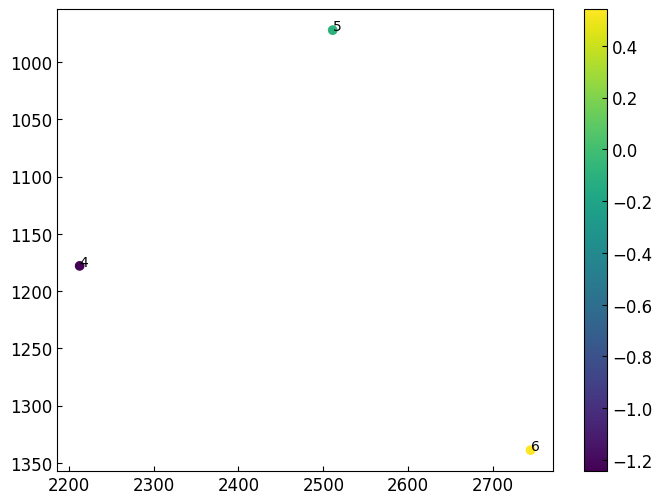

vertical coma
mean value : -0.65288004919715


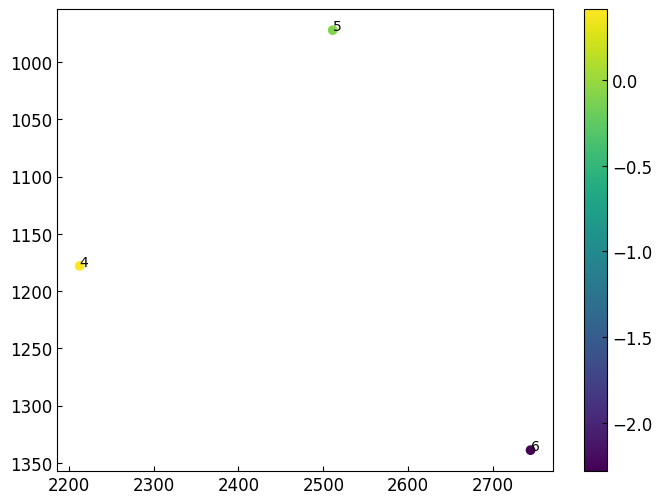

horizontal coma
mean value : -0.618977775118119


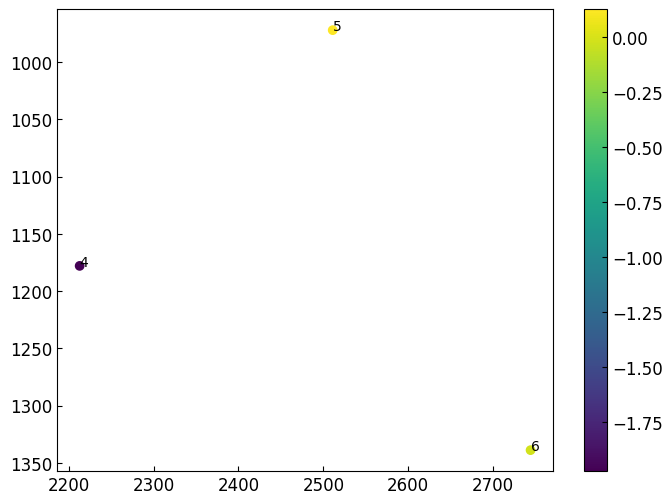

C:\Users\Tommy\AppData\Local\Temp\ipykernel_5412\777963035.py:34: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  ax.scatter(x0s, y0s, cmap='viridis')


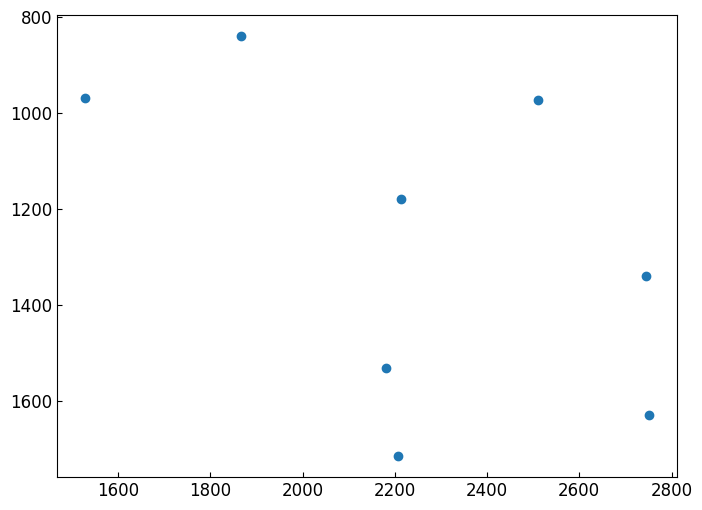

: 

In [ ]:
print(spherical)
plt.figure()
print('spherical')
print('mean value : ' + str(np.mean(spherical)))
ax=plt.subplot()
data = ax.scatter(xs, ys, c = np.array(spherical), cmap='viridis')
plt.colorbar(data)
ax.invert_yaxis()
for i, txt in enumerate(ns):
    ax.annotate(txt, (xs[i], ys[i]))
plt.show()

print('vertical coma')
print('mean value : ' + str(np.mean(v_coma)))
ax=plt.subplot()
data = ax.scatter(xs, ys, c = np.array(v_coma), cmap='viridis')
plt.colorbar(data)
ax.invert_yaxis()
for i, txt in enumerate(ns):
    ax.annotate(txt, (xs[i], ys[i]))
plt.show()

print('horizontal coma')
print('mean value : ' + str(np.mean(h_coma)))
ax = plt.subplot()
data = ax.scatter(xs, ys, c = np.array(h_coma), cmap='viridis')
plt.colorbar(data)
ax.invert_yaxis()
for i, txt in enumerate(ns):
    ax.annotate(txt, (xs[i], ys[i]))
plt.show()

ax = plt.subplot()
ax.scatter(x0s, y0s, cmap='viridis')
ax.invert_yaxis()
plt.show()